In [1]:
import os
import sys
import math
import numpy as np
import matplotlib.pyplot as plt

from spisea import synthetic, evolution, atmospheres, reddening
from nbody6tools import Reader
from nbody62spisea import converter

/home/wyz5rge/.local/lib/python3.6/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /scratch/wyz5rge/models/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


In [2]:
sys.path.append('/scratch/wyz5rge/synthetic-hr/cmd_generator')
import interpolator as interpolator

In [3]:
# -----------------------------
# SPISEA / photometry settings
# -----------------------------
AKs = 0
dist = 410
metallicity = 0

evo_model = evolution.Baraffe15()
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawHosek18b()

filt_list = ['jwst,F162M', 'jwst,F182M']
filters = ['m_jwst_F162M', 'm_jwst_F182M']

iso_dir = 'isochrones/'

# -----------------------------
# Simulation paths
# -----------------------------
BASE_HIGH_DENSITY = '/storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0'
BASE_LOW_DENSITY  = '/storage/jfarias/Data/Orion/newbinaries/M3000sigma0.1'

SIM_PATHS = {
    # high density
    '1.0_0.01': os.path.join(BASE_HIGH_DENSITY, 'sfeff001_00') + '/',
    '1.0_0.03': os.path.join(BASE_HIGH_DENSITY, 'sfeff003_00') + '/',
    '1.0_0.10': os.path.join(BASE_HIGH_DENSITY, 'sfeff010_00') + '/',
    '1.0_0.30': os.path.join(BASE_HIGH_DENSITY, 'sfeff030_00') + '/',
    '1.0_1.00': os.path.join(BASE_HIGH_DENSITY, 'sfeff100_00') + '/',

    # low density
    '0.1_0.01': os.path.join(BASE_LOW_DENSITY, 'sfeff001_00') + '/',
    '0.1_0.03': os.path.join(BASE_LOW_DENSITY, 'sfeff003_00') + '/',
    '0.1_0.10': os.path.join(BASE_LOW_DENSITY, 'sfeff010_00') + '/',
    '0.1_0.30': os.path.join(BASE_LOW_DENSITY, 'sfeff030_00') + '/',
    '0.1_1.00': os.path.join(BASE_LOW_DENSITY, 'sfeff100_00') + '/',
}

# -----------------------------
# Formation times (Myr)
# provided by you
# -----------------------------
T_FF_BY_EFF = {
    0.01: 19.40,
    0.03:  6.47,
    0.10:  1.94,
    0.30:  0.65,
    1.00:  0.19,
}

In [4]:
def cmd_coords_from_star(star):
    """
    Assumes:
      star[3] = F162M
      star[4] = F182M
    Returns:
      color = F162M - F182M
      mag   = F162M
    """
    if star is None:
        return None
    color = star[3] - star[4]
    mag = star[3]
    return color, mag

def euclidean_cmd_distance(color1, mag1, color2, mag2):
    return np.sqrt((color1 - color2)**2 + (mag1 - mag2)**2)


def load_cluster_table(sim_path, snapshot_time_myr):
    """
    Reads an N-body snapshot at a given time in Myr using Reader.read_snapshot(..., time=...),
    converts to physical units, and returns a SPISEA-style cluster table.
    """
    sim_path = os.path.abspath(sim_path)
    if not sim_path.endswith('/'):
        sim_path += '/'

    print("Loading from:", sim_path)
    snapshot = Reader.read_snapshot(sim_path, time=snapshot_time_myr)
    snapshot.to_physical()
    cluster_table = converter.to_spicea_table(snapshot)
    return cluster_table


def extract_masses_and_ages(cluster_table):
    """
    Returns primary masses and ages in both Myr and yr.
    """
    masses = np.array(cluster_table['mass'], dtype=float)
    ages_myr = np.array(cluster_table['age'], dtype=float)   # seems already in Myr from your prior notebook
    ages_yr = ages_myr * 1e6
    return masses, ages_myr, ages_yr


def build_isochrone_grid(
    ages_yr,
    global_oldest_age_yr=None,
    increment_yr=0.1e6,
    min_age_floor_yr=0.5e6,
):
    """
    Build a grid of SPISEA isochrones covering the ages in this snapshot.
    
    If global_oldest_age_yr is supplied, the grid is extended to include it.
    """
    min_age = np.min(ages_yr)
    max_age = np.max(ages_yr)

    if global_oldest_age_yr is not None:
        max_age = max(max_age, global_oldest_age_yr)

    start = max(min_age_floor_yr, math.floor(min_age / increment_yr) * increment_yr)
    end   = math.ceil(max_age / increment_yr) * increment_yr + increment_yr

    level_age_arr_yr = np.arange(start, end + 0.5 * increment_yr, increment_yr)
    log_age_arr = np.log10(level_age_arr_yr)

    instances = np.empty(len(log_age_arr), dtype=object)
    for i, log_age in enumerate(log_age_arr):
        instances[i] = synthetic.IsochronePhot(
            log_age, AKs, dist,
            metallicity=metallicity,
            evo_model=evo_model,
            atm_func=atm_func,
            red_law=red_law,
            filters=filt_list,
            iso_dir=iso_dir
        )

    return level_age_arr_yr, log_age_arr, instances


def build_single_isochrone(age_yr):
    return synthetic.IsochronePhot(
        np.log10(age_yr), AKs, dist,
        metallicity=metallicity,
        evo_model=evo_model,
        atm_func=atm_func,
        red_law=red_law,
        filters=filt_list,
        iso_dir=iso_dir
    )


def interpolate_star(age_myr, mass, instances, log_age_arr, filters):
    """
    Wrapper around your custom interpolator.
    """
    return interpolator.interpolate(age_myr, mass, instances, log_age_arr, filters)


def interpolate_star_on_fixed_age_isochrone(age_myr_fixed, mass, instances, log_age_arr, filters):
    """
    Interpolate a star of a given mass at a fixed age using the same interpolator.
    """
    return interpolator.interpolate(age_myr_fixed, mass, instances, log_age_arr, filters)


def compute_oldest_anchor_distances(cluster_table, global_oldest_age_myr=None, increment_yr=0.1e6):
    """
    For each star in the snapshot:
      - interpolate its actual CMD position using its true age and mass
      - interpolate the CMD position of a star of the same mass on the oldest isochrone
      - compute Euclidean CMD distance between those two positions

    If global_oldest_age_myr is None, uses the oldest stellar age in this snapshot.
    Otherwise anchors to the supplied global oldest age.
    """
    masses, ages_myr, ages_yr = extract_masses_and_ages(cluster_table)

    if global_oldest_age_myr is None:
        oldest_age_myr = np.max(ages_myr)
        global_oldest_age_yr = np.max(ages_yr)
    else:
        oldest_age_myr = global_oldest_age_myr
        global_oldest_age_yr = global_oldest_age_myr * 1e6

    level_age_arr_yr, log_age_arr, instances = build_isochrone_grid(
        ages_yr,
        global_oldest_age_yr=global_oldest_age_yr,
        increment_yr=increment_yr
    )

    distances = []
    valid_masses = []
    actual_points = []
    oldest_points = []

    for mass, age_myr in zip(masses, ages_myr):
        actual_star = interpolate_star(age_myr, mass, instances, log_age_arr, filters)
        old_star    = interpolate_star_on_fixed_age_isochrone(oldest_age_myr, mass, instances, log_age_arr, filters)

        if actual_star is None or old_star is None:
            continue

        actual_cmd = cmd_coords_from_star(actual_star)
        oldest_cmd = cmd_coords_from_star(old_star)

        if actual_cmd is None or oldest_cmd is None:
            continue

        d = euclidean_cmd_distance(actual_cmd[0], actual_cmd[1], oldest_cmd[0], oldest_cmd[1])

        distances.append(d)
        valid_masses.append(mass)
        actual_points.append(actual_cmd)
        oldest_points.append(oldest_cmd)

    return {
        'masses': np.array(valid_masses),
        'distances': np.array(distances),
        'actual_points': np.array(actual_points),
        'oldest_points': np.array(oldest_points),
        'oldest_age_myr': oldest_age_myr,
    }


def compute_percentile_isochrone_separation(cluster_table, increment_yr=0.1e6):
    """
    Uses only isochrones:
      - compute 5th and 95th percentile stellar ages in the snapshot
      - generate isochrones at those ages
      - for each stellar mass present in the snapshot, interpolate the CMD point
        on both isochrones at that mass
      - compute Euclidean distance between those two isochrone positions

    Returns per-mass separations and summary statistics.
    """
    masses, ages_myr, ages_yr = extract_masses_and_ages(cluster_table)

    age5_myr  = np.percentile(ages_myr, 5)
    age95_myr = np.percentile(ages_myr, 95)

    # Build a grid containing both percentile ages so the same interpolator can be reused
    synthetic_age_yr = np.array([age5_myr * 1e6, age95_myr * 1e6])

    level_age_arr_yr, log_age_arr, instances = build_isochrone_grid(
        synthetic_age_yr,
        global_oldest_age_yr=np.max(synthetic_age_yr),
        increment_yr=increment_yr
    )

    separations = []
    valid_masses = []
    p5_points = []
    p95_points = []

    for mass in masses:
        star5  = interpolate_star(age5_myr,  mass, instances, log_age_arr, filters)
        star95 = interpolate_star(age95_myr, mass, instances, log_age_arr, filters)

        if star5 is None or star95 is None:
            continue

        cmd5  = cmd_coords_from_star(star5)
        cmd95 = cmd_coords_from_star(star95)

        if cmd5 is None or cmd95 is None:
            continue

        d = euclidean_cmd_distance(cmd5[0], cmd5[1], cmd95[0], cmd95[1])

        separations.append(d)
        valid_masses.append(mass)
        p5_points.append(cmd5)
        p95_points.append(cmd95)

    return {
        'masses': np.array(valid_masses),
        'distances': np.array(separations),
        'age5_myr': age5_myr,
        'age95_myr': age95_myr,
        'p5_points': np.array(p5_points),
        'p95_points': np.array(p95_points),
    }


def summarize_distances(distance_array):
    return {
        'mean': np.mean(distance_array) if len(distance_array) > 0 else np.nan,
        'median': np.median(distance_array) if len(distance_array) > 0 else np.nan,
        'std': np.std(distance_array) if len(distance_array) > 0 else np.nan,
    }


def compute_age_spread(cluster_table, low=5, high=95):
    _, ages_myr, _ = extract_masses_and_ages(cluster_table)
    return np.percentile(ages_myr, high) - np.percentile(ages_myr, low)

In [5]:
sim_key = '1.0_0.03'
snapshot_time_myr = 1.5

cluster_table = load_cluster_table(SIM_PATHS[sim_key], snapshot_time_myr)

# Method 1: anchor to oldest isochrone in this snapshot
oldest_metric = compute_oldest_anchor_distances(cluster_table)

# Method 2: 5th-95th percentile isochrone separation
percentile_metric = compute_percentile_isochrone_separation(cluster_table)

Loading from: /storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0/sfeff003_00/
Isochrone generation took 1.142265 s.
Making photometry for isochrone: log(t) = 5.70  AKs = 0.00  dist = 410
     Starting at:  2026-03-23 23:54:39.220184   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2387 K  m_jwst_F162M = 16.25
Starting filter: jwst,F182M   Elapsed time: 0.64 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2387 K  m_jwst_F182M = 16.41
      Time taken: 1.28 seconds
Isochrone generation took 1.332462 s.
Making photometry for isochrone: log(t) = 5.78  AKs = 0.00  dist = 410
     Starting at:  2026-03-23 23:54:41.847592   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2382 K  m_jwst_F162M = 16.38
Starting filter: jwst,F182M   Elapsed time: 0.74 seconds
Starting synthetic photometry
M =   0.010 Msun  T 

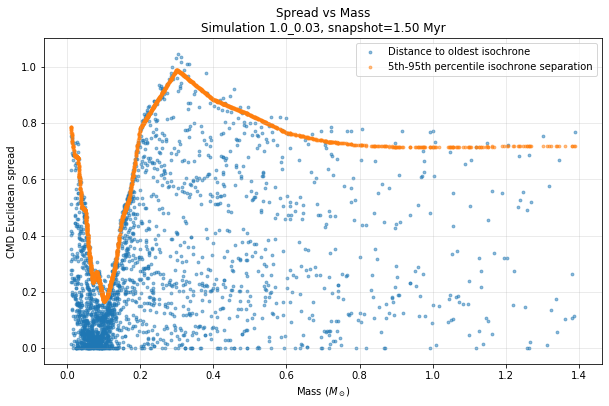

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(oldest_metric['masses'], oldest_metric['distances'], s=8, alpha=0.5, label='Distance to oldest isochrone')
plt.scatter(percentile_metric['masses'], percentile_metric['distances'], s=8, alpha=0.5, label='5th-95th percentile isochrone separation')

plt.xlabel('Mass ($M_\\odot$)')
plt.ylabel('CMD Euclidean spread')
plt.title(f'Spread vs Mass\nSimulation {sim_key}, snapshot={snapshot_time_myr:.2f} Myr')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

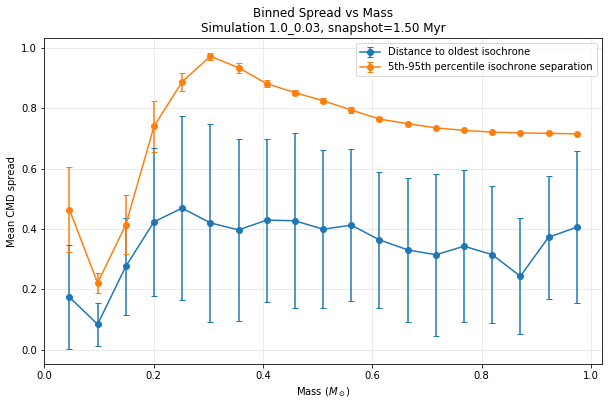

In [7]:
def binned_mean(x, y, bins):
    inds = np.digitize(x, bins)
    xmid, ymean, ystd, counts = [], [], [], []

    for i in range(1, len(bins)):
        mask = inds == i
        if np.sum(mask) == 0:
            continue
        xmid.append(0.5 * (bins[i-1] + bins[i]))
        ymean.append(np.mean(y[mask]))
        ystd.append(np.std(y[mask]))
        counts.append(np.sum(mask))

    return np.array(xmid), np.array(ymean), np.array(ystd), np.array(counts)


bins = np.linspace(0.02, 1.0, 20)

x1, y1, y1std, n1 = binned_mean(oldest_metric['masses'], oldest_metric['distances'], bins)
x2, y2, y2std, n2 = binned_mean(percentile_metric['masses'], percentile_metric['distances'], bins)

plt.figure(figsize=(10, 6))
plt.errorbar(x1, y1, yerr=y1std, fmt='o-', capsize=3, label='Distance to oldest isochrone')
plt.errorbar(x2, y2, yerr=y2std, fmt='o-', capsize=3, label='5th-95th percentile isochrone separation')

plt.xlabel('Mass ($M_\\odot$)')
plt.ylabel('Mean CMD spread')
plt.title(f'Binned Spread vs Mass\nSimulation {sim_key}, snapshot={snapshot_time_myr:.2f} Myr')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [8]:
sim_key = '1.0_0.03'
snapshot_times_myr = np.arange(0.2, 6.6, 0.2)  # adjust to available snapshots

times = []
oldest_mean_spread = []
oldest_median_spread = []
percentile_mean_spread = []
age_spreads = []

for t in snapshot_times_myr:
    try:
        cluster_table = load_cluster_table(SIM_PATHS[sim_key], t)

        oldest_metric = compute_oldest_anchor_distances(cluster_table)
        percentile_metric = compute_percentile_isochrone_separation(cluster_table)

        s_oldest = summarize_distances(oldest_metric['distances'])
        s_pct = summarize_distances(percentile_metric['distances'])
        age_spread = compute_age_spread(cluster_table)

        times.append(t)
        oldest_mean_spread.append(s_oldest['mean'])
        oldest_median_spread.append(s_oldest['median'])
        percentile_mean_spread.append(s_pct['mean'])
        age_spreads.append(age_spread)

        print(f't={t:.2f} Myr complete')

    except Exception as e:
        print(f't={t:.2f} Myr failed: {e}')
        continue

times = np.array(times)
oldest_mean_spread = np.array(oldest_mean_spread)
oldest_median_spread = np.array(oldest_median_spread)
percentile_mean_spread = np.array(percentile_mean_spread)
age_spreads = np.array(age_spreads)

Loading from: /storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0/sfeff003_00/
t=0.20 Myr failed: index 0 is out of bounds for axis 0 with size 0
Loading from: /storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0/sfeff003_00/


/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:94: RuntimeWarning: divide by zero encountered in double_scalars
  w1 = (np.power(10, age_arr[a2]) / 1000000 - age) / (np.power(10, age_arr[a2]) / 1000000 - np.power(10, age_arr[a1]) / 1000000)
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:99: RuntimeWarning: invalid value encountered in double_scalars
  s_lum = w1 * s1[1] + w2 * s2[1]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:100: RuntimeWarning: invalid value encountered in double_scalars
  s_teff = w1 * s1[2] + w2 * s2[2]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:101: RuntimeWarning: invalid value encountered in double_scalars
  s_logg = w1 * s1[3] + w2 * s2[3]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:102: RuntimeWarning: invalid value encountered in double_scalars
  s_filt1 = w1 * s1[4] + w2 * s2[4]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:103: RuntimeWarning: invalid value encountered 

t=0.40 Myr complete
Loading from: /storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0/sfeff003_00/


/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:94: RuntimeWarning: divide by zero encountered in double_scalars
  w1 = (np.power(10, age_arr[a2]) / 1000000 - age) / (np.power(10, age_arr[a2]) / 1000000 - np.power(10, age_arr[a1]) / 1000000)
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:99: RuntimeWarning: invalid value encountered in double_scalars
  s_lum = w1 * s1[1] + w2 * s2[1]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:100: RuntimeWarning: invalid value encountered in double_scalars
  s_teff = w1 * s1[2] + w2 * s2[2]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:101: RuntimeWarning: invalid value encountered in double_scalars
  s_logg = w1 * s1[3] + w2 * s2[3]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:102: RuntimeWarning: invalid value encountered in double_scalars
  s_filt1 = w1 * s1[4] + w2 * s2[4]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:103: RuntimeWarning: invalid value encountered 

t=0.60 Myr complete
Loading from: /storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0/sfeff003_00/


...

/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:94: RuntimeWarning: divide by zero encountered in double_scalars
  w1 = (np.power(10, age_arr[a2]) / 1000000 - age) / (np.power(10, age_arr[a2]) / 1000000 - np.power(10, age_arr[a1]) / 1000000)
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:99: RuntimeWarning: invalid value encountered in double_scalars
  s_lum = w1 * s1[1] + w2 * s2[1]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:100: RuntimeWarning: invalid value encountered in double_scalars
  s_teff = w1 * s1[2] + w2 * s2[2]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:101: RuntimeWarning: invalid value encountered in double_scalars
  s_logg = w1 * s1[3] + w2 * s2[3]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:102: RuntimeWarning: invalid value encountered in double_scalars
  s_filt1 = w1 * s1[4] + w2 * s2[4]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:103: RuntimeWarning: invalid value encountered 

t=1.40 Myr complete
Loading from: /storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0/sfeff003_00/
Isochrone generation took 1.318189 s.
Making photometry for isochrone: log(t) = 6.23  AKs = 0.00  dist = 410
     Starting at:  2026-03-23 23:56:00.259711   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2267 K  m_jwst_F162M = 17.26
Starting filter: jwst,F182M   Elapsed time: 0.73 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2267 K  m_jwst_F182M = 17.48
      Time taken: 1.47 seconds
t=1.60 Myr complete
Loading from: /storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0/sfeff003_00/
Isochrone generation took 1.313094 s.
Making photometry for isochrone: log(t) = 6.26  AKs = 0.00  dist = 410
     Starting at:  2026-03-23 23:56:13.489779   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2259 K  m_jwst_

Isochrone generation took 1.312781 s.
Making photometry for isochrone: log(t) = 6.51  AKs = 0.00  dist = 410
     Starting at:  2026-03-23 23:57:55.166663   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2125 K  m_jwst_F162M = 17.86
Starting filter: jwst,F182M   Elapsed time: 0.74 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2125 K  m_jwst_F182M = 18.15
      Time taken: 1.46 seconds
Isochrone generation took 1.316834 s.
Making photometry for isochrone: log(t) = 6.52  AKs = 0.00  dist = 410
     Starting at:  2026-03-23 23:57:57.959113   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2119 K  m_jwst_F162M = 17.88
Starting filter: jwst,F182M   Elapsed time: 0.73 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2119 K  m_jwst_F182M = 18.18
      Time taken: 1.46 seconds
Isochrone generati

Starting filter: jwst,F182M   Elapsed time: 0.78 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1989 K  m_jwst_F182M = 18.65
      Time taken: 1.54 seconds
t=4.60 Myr complete
Loading from: /storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0/sfeff003_00/
Changing to logg=5.00 for T=  1975 logg=3.94
Isochrone generation took 1.347301 s.
Making photometry for isochrone: log(t) = 6.68  AKs = 0.00  dist = 410
     Starting at:  2026-03-23 23:59:53.236673   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1975 K  m_jwst_F162M = 18.30
Starting filter: jwst,F182M   Elapsed time: 0.75 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1975 K  m_jwst_F182M = 18.67
      Time taken: 1.50 seconds
Changing to logg=5.00 for T=  1960 logg=3.95
Isochrone generation took 1.295918 s.
Making photometry for isochrone: log(t) = 6.69  AKs = 0.00  dist = 410
     Starting at:  2026-03-23 23:59:56.

Starting filter: jwst,F182M   Elapsed time: 0.74 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  1846 K  m_jwst_F182M = 18.99
      Time taken: 1.47 seconds
t=6.20 Myr complete
Loading from: /storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0/sfeff003_00/
t=6.40 Myr complete


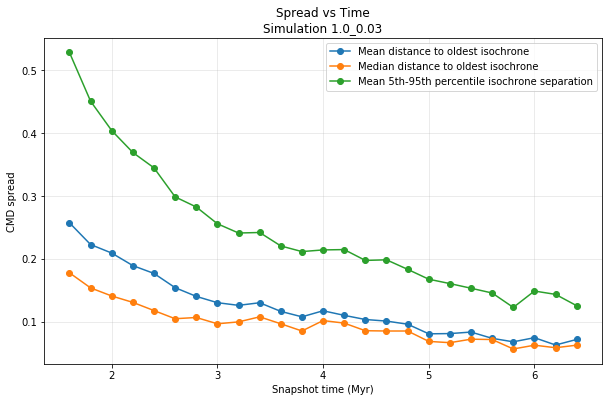

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(times, oldest_mean_spread, marker='o', label='Mean distance to oldest isochrone')
plt.plot(times, oldest_median_spread, marker='o', label='Median distance to oldest isochrone')
plt.plot(times, percentile_mean_spread, marker='o', label='Mean 5th-95th percentile isochrone separation')

plt.xlabel('Snapshot time (Myr)')
plt.ylabel('CMD spread')
plt.title(f'Spread vs Time\nSimulation {sim_key}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [10]:
efficiencies = [0.01, 0.03, 0.10, 0.30, 1.00]

results = []

for eff in efficiencies:
    sim_key = f'1.0_{eff:.2f}'
    sim_path = SIM_PATHS[sim_key]
    t_ff = T_FF_BY_EFF[eff]

    # Choose a time sampling up to roughly the formation time
    # You can extend farther if you want to capture plateau behavior after formation slows.
    snapshot_times_myr = np.arange(0.2, max(t_ff, 0.4) + 0.21, 0.2)

    for t in snapshot_times_myr:
        try:
            cluster_table = load_cluster_table(sim_path, t)

            oldest_metric = compute_oldest_anchor_distances(cluster_table)
            percentile_metric = compute_percentile_isochrone_separation(cluster_table)

            s_oldest = summarize_distances(oldest_metric['distances'])
            s_pct = summarize_distances(percentile_metric['distances'])
            age_spread = compute_age_spread(cluster_table)

            results.append({
                'eff': eff,
                't_myr': t,
                't_over_tff': t / t_ff,
                'age_spread_myr': age_spread,
                'oldest_mean_spread': s_oldest['mean'],
                'oldest_median_spread': s_oldest['median'],
                'pct_mean_spread': s_pct['mean'],
            })

            print(f'eff={eff:.2f}, t={t:.2f} done')

        except Exception as e:
            print(f'eff={eff:.2f}, t={t:.2f} failed: {e}')
            continue

Loading from: /storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0/sfeff001_00/
eff=0.01, t=0.20 failed: index 0 is out of bounds for axis 0 with size 0
Loading from: /storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0/sfeff001_00/


/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:94: RuntimeWarning: divide by zero encountered in double_scalars
  w1 = (np.power(10, age_arr[a2]) / 1000000 - age) / (np.power(10, age_arr[a2]) / 1000000 - np.power(10, age_arr[a1]) / 1000000)
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:99: RuntimeWarning: invalid value encountered in double_scalars
  s_lum = w1 * s1[1] + w2 * s2[1]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:100: RuntimeWarning: invalid value encountered in double_scalars
  s_teff = w1 * s1[2] + w2 * s2[2]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:101: RuntimeWarning: invalid value encountered in double_scalars
  s_logg = w1 * s1[3] + w2 * s2[3]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:102: RuntimeWarning: invalid value encountered in double_scalars
  s_filt1 = w1 * s1[4] + w2 * s2[4]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:103: RuntimeWarning: invalid value encountered 

eff=0.01, t=0.40 done
Loading from: /storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0/sfeff001_00/


/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:94: RuntimeWarning: divide by zero encountered in double_scalars
  w1 = (np.power(10, age_arr[a2]) / 1000000 - age) / (np.power(10, age_arr[a2]) / 1000000 - np.power(10, age_arr[a1]) / 1000000)
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:99: RuntimeWarning: invalid value encountered in double_scalars
  s_lum = w1 * s1[1] + w2 * s2[1]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:100: RuntimeWarning: invalid value encountered in double_scalars
  s_teff = w1 * s1[2] + w2 * s2[2]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:101: RuntimeWarning: invalid value encountered in double_scalars
  s_logg = w1 * s1[3] + w2 * s2[3]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:102: RuntimeWarning: invalid value encountered in double_scalars
  s_filt1 = w1 * s1[4] + w2 * s2[4]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:103: RuntimeWarning: invalid value encountered 

eff=0.01, t=0.60 done
Loading from: /storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0/sfeff001_00/


...

eff=0.30, t=0.40 done
Loading from: /storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0/sfeff030_00/


/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:94: RuntimeWarning: divide by zero encountered in double_scalars
  w1 = (np.power(10, age_arr[a2]) / 1000000 - age) / (np.power(10, age_arr[a2]) / 1000000 - np.power(10, age_arr[a1]) / 1000000)
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:99: RuntimeWarning: invalid value encountered in double_scalars
  s_lum = w1 * s1[1] + w2 * s2[1]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:100: RuntimeWarning: invalid value encountered in double_scalars
  s_teff = w1 * s1[2] + w2 * s2[2]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:101: RuntimeWarning: invalid value encountered in double_scalars
  s_logg = w1 * s1[3] + w2 * s2[3]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:102: RuntimeWarning: invalid value encountered in double_scalars
  s_filt1 = w1 * s1[4] + w2 * s2[4]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:103: RuntimeWarning: invalid value encountered 

eff=0.30, t=0.60 done
Loading from: /storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0/sfeff030_00/
eff=0.30, t=0.80 done
Loading from: /storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0/sfeff100_00/
eff=1.00, t=0.20 failed: index 0 is out of bounds for axis 0 with size 0
Loading from: /storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0/sfeff100_00/


/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:94: RuntimeWarning: divide by zero encountered in double_scalars
  w1 = (np.power(10, age_arr[a2]) / 1000000 - age) / (np.power(10, age_arr[a2]) / 1000000 - np.power(10, age_arr[a1]) / 1000000)
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:99: RuntimeWarning: invalid value encountered in double_scalars
  s_lum = w1 * s1[1] + w2 * s2[1]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:100: RuntimeWarning: invalid value encountered in double_scalars
  s_teff = w1 * s1[2] + w2 * s2[2]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:101: RuntimeWarning: invalid value encountered in double_scalars
  s_logg = w1 * s1[3] + w2 * s2[3]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:102: RuntimeWarning: invalid value encountered in double_scalars
  s_filt1 = w1 * s1[4] + w2 * s2[4]
/scratch/wyz5rge/synthetic-hr/cmd_generator/interpolator.py:103: RuntimeWarning: invalid value encountered 

eff=1.00, t=0.40 done
Loading from: /storage/jfarias/Data/Orion/newbinaries/M3000sigma1.0/sfeff100_00/
eff=1.00, t=0.60 done


In [11]:
import pandas as pd

df = pd.DataFrame(results)
df.head()

,eff,t_myr,t_over_tff,age_spread_myr,oldest_mean_spread,oldest_median_spread,pct_mean_spread
0,0.01,0.4,0.020619,0.406531,NaN,NaN,NaN
1,0.01,0.6,0.030928,0.587585,NaN,NaN,NaN
2,0.01,0.8,0.041237,0.756639,NaN,NaN,NaN
3,0.01,1.0,0.051546,0.851969,NaN,NaN,NaN
4,0.01,1.2,0.061856,1.142883,NaN,NaN,NaN


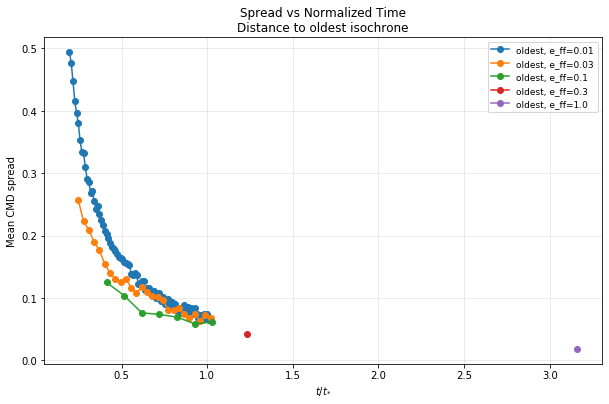

In [27]:
plt.figure(figsize=(10, 6))

for eff in efficiencies:
    sub = df[df['eff'] == eff].sort_values('t_over_tff')
    plt.plot(sub['t_over_tff'], sub['oldest_mean_spread'], marker='o', label=f'oldest, e_ff={eff}')
    
# plt.xscale('log')
plt.xlabel(r'$t / t_{\mathrm{*}}$')
plt.ylabel('Mean CMD spread')
plt.title('Spread vs Normalized Time\nDistance to oldest isochrone')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

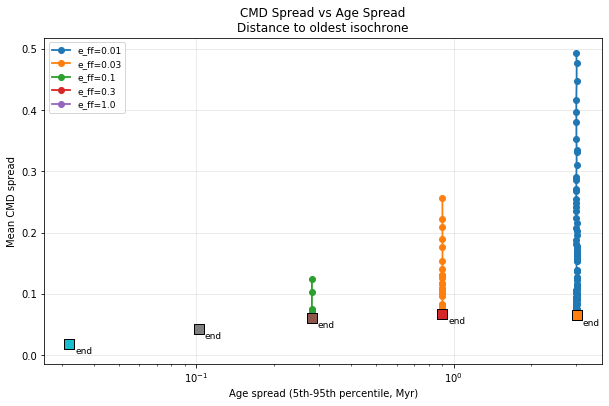

In [23]:
plt.figure(figsize=(10, 6))

for eff in efficiencies:
    sub = df[df['eff'] == eff].sort_values('t_over_tff').copy()

    x = sub['age_spread_myr'].values
    y = sub['oldest_mean_spread'].values

    plt.plot(x, y, marker='o', linewidth=1.8, label=f'e_ff={eff}')

    if len(x) > 0:
        # START point (early time)
        plt.scatter(x[0], y[0], s=100, marker='o', edgecolor='k', zorder=5)
        plt.annotate(
            'start',
            (x[0], y[0]),
            xytext=(6, 6),
            textcoords='offset points',
            fontsize=9
        )

        # END point (late time)
        plt.scatter(x[-1], y[-1], s=120, marker='s', edgecolor='k', zorder=5)
        plt.annotate(
            'end',
            (x[-1], y[-1]),
            xytext=(6, -10),
            textcoords='offset points',
            fontsize=9
        )

plt.xscale('log')

plt.xlabel('Age spread (5th-95th percentile, Myr)')
plt.ylabel('Mean CMD spread')
plt.title('CMD Spread vs Age Spread\nDistance to oldest isochrone')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

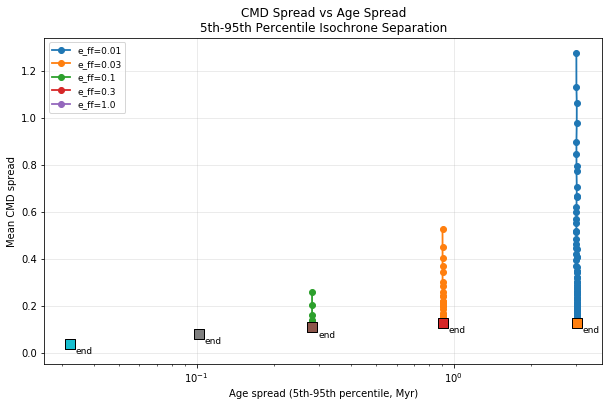

In [25]:
plt.figure(figsize=(10, 6))

for eff in efficiencies:
    sub = df[df['eff'] == eff].sort_values('t_over_tff').copy()

    x = sub['age_spread_myr'].values
    y = sub['pct_mean_spread'].values

    plt.plot(x, y, marker='o', linewidth=1.8, label=f'e_ff={eff}')

    if len(x) > 0:
        plt.scatter(x[0], y[0], s=100, marker='o', edgecolor='k', zorder=5)
        plt.annotate('start', (x[0], y[0]), xytext=(6, 6),
                     textcoords='offset points', fontsize=9)

        plt.scatter(x[-1], y[-1], s=120, marker='s', edgecolor='k', zorder=5)
        plt.annotate('end', (x[-1], y[-1]), xytext=(6, -10),
                     textcoords='offset points', fontsize=9)

plt.xscale('log')
        
plt.xlabel('Age spread (5th-95th percentile, Myr)')
plt.ylabel('Mean CMD spread')
plt.title('CMD Spread vs Age Spread\n5th-95th Percentile Isochrone Separation')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()